# Day 02. 텐서와 경사하강법

## 1) 오늘의 학습 목표

- 스칼라, 벡터, 행렬을 텐서 관점으로 구분
- PyTorch Tensor의 `shape`, `dtype`, 기본 연산을 확인
- `requires_grad`와 `loss.backward()`로 자동미분 이해
- 수치 미분과 경사하강법을 NumPy로 직접 실행


## 2) 텐서
텐서는 숫자를 담는 다차원 배열입니다. 딥러닝에서는 입력 데이터, 가중치, 예측값, 손실값이 모두 텐서 형태로 움직입니다.  
학습은 손실이 줄어드는 방향으로 파라미터를 조금씩 고치는 과정이며, 그 방향을 알려주는 값이 기울기입니다.


## PyTorch 실행 환경 확인

PyTorch는 딥러닝 모델을 만들 때 자주 쓰는 프레임워크입니다. 아래 셀은 `torch` import가 되는지 확인하고, GPU가 있으면 `cuda`, 없으면 `cpu`를 자동으로 선택합니다. 오늘 실습은 GPU가 없어도 충분히 빠르게 실행됩니다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

plt.rcParams["figure.figsize"] = (6, 4)

print("PyTorch version:", torch.__version__)    # 파이토치 버전 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 device:", device)

if device.type == "cuda":
    print("GPU 이름:", torch.cuda.get_device_name(0))
else:
    print("GPU가 없어도 이번 보충 실습은 CPU로 실행 가능합니다.")


PyTorch version: 2.10.0+cpu
사용 device: cpu
GPU가 없어도 이번 보충 실습은 CPU로 실행 가능합니다.


## 3) 예제: 리스트, NumPy 배열, Tensor 비교

Tensor는 NumPy 배열과 비슷하지만, GPU 이동과 자동미분 같은 딥러닝 기능을 함께 제공합니다.


In [ ]:
python_list = [1, 2, 3]
numpy_array = np.array([1, 2, 3])
torch_tensor = torch.tensor([1, 2, 3], dtype=torch.float32, device=device)

print("Python list:", python_list)
print("NumPy array:", numpy_array, numpy_array.shape, numpy_array.dtype)
print("Torch tensor:", torch_tensor, torch_tensor.shape, torch_tensor.dtype)
print("Tensor 기본 연산:", torch_tensor + 10, torch_tensor * 2)


Python list: [1, 2, 3]
NumPy array: [1 2 3] (3,) int64
Torch tensor: tensor([1., 2., 3.]) torch.Size([3]) torch.float32
Tensor 기본 연산: tensor([11., 12., 13.]) tensor([2., 4., 6.])


## 4) 실습: autograd로 기울기 계산하기

`requires_grad=True`로 만든 값은 계산 과정을 기록합니다. 마지막에 `loss.backward()`를 실행하면 손실을 줄이기 위해 어느 방향으로 바꿔야 하는지 `grad`에 저장됩니다.


In [ ]:
w = torch.tensor(2.0, requires_grad=True, device=device)
b = torch.tensor(-1.0, requires_grad=True, device=device)
x_value = torch.tensor(3.0, device=device)
target = torch.tensor(7.0, device=device)

prediction = w * x_value + b
loss = (prediction - target) ** 2
loss.backward() # 기울기만 계산, 파라미터 업데이트X
# 파라미터 업데이트는 optimizer로!!

print("예측값:", round(float(prediction.detach().cpu()), 3))
print("손실값:", round(float(loss.detach().cpu()), 3))
print("w의 gradient:", round(float(w.grad.detach().cpu()), 3))
print("b의 gradient:", round(float(b.grad.detach().cpu()), 3))


예측값: 5.0
손실값: 4.0
w의 gradient: -12.0
b의 gradient: -4.0


## 5) 실습 TODO: autograd 값 바꿔보기

아래 셀에서 `todo_x`, `todo_target`, `todo_w` 값을 바꾸고 gradient가 어떻게 달라지는지 확인하세요.


In [ ]:
# TODO: 입력값, 정답, 초기 w를 바꿔 gradient 변화를 관찰해 보세요.
todo_x = torch.tensor(4.0, device=device)
todo_target = torch.tensor(10.0, device=device)
todo_w = torch.tensor(1.0, requires_grad=True, device=device)
todo_b = torch.tensor(0.0, requires_grad=True, device=device)

todo_pred = todo_w * todo_x + todo_b
todo_loss = (todo_pred - todo_target) ** 2
todo_loss.backward()

print("todo 예측:", round(float(todo_pred.detach().cpu()), 3))
print("todo 손실:", round(float(todo_loss.detach().cpu()), 3))
print("todo_w.grad:", round(float(todo_w.grad.detach().cpu()), 3))
print("todo_b.grad:", round(float(todo_b.grad.detach().cpu()), 3))


todo 예측: 4.0
todo 손실: 36.0
todo_w.grad: -48.0
todo_b.grad: -12.0


## 6) 예제: 벡터와 행렬 곱

입력값과 가중치를 곱하고 편향을 더하면 가장 단순한 예측 함수가 됩니다.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 4)

x = np.array([2.0, 3.0])          # 입력 벡터
w = np.array([0.7, -0.2])         # 가중치 벡터
b = 1.5                           # 편향

prediction = x @ w + b

print("x shape:", x.shape)
print("w shape:", w.shape)
print("예측값:", prediction)

x shape: (2,)
w shape: (2,)
예측값: 2.3


## 7) 실습: 수치 미분으로 기울기 이해

`f(x) = (x - 3)^2`는 x가 3일 때 가장 작습니다. 아주 작은 값을 더하고 빼서 기울기를 근사해 봅니다.


x=-1, f(x)=16.00, 기울기≈ -8.00
x= 0, f(x)= 9.00, 기울기≈ -6.00
x= 2, f(x)= 1.00, 기울기≈ -2.00
x= 3, f(x)= 0.00, 기울기≈  0.00
x= 5, f(x)= 4.00, 기울기≈  4.00


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


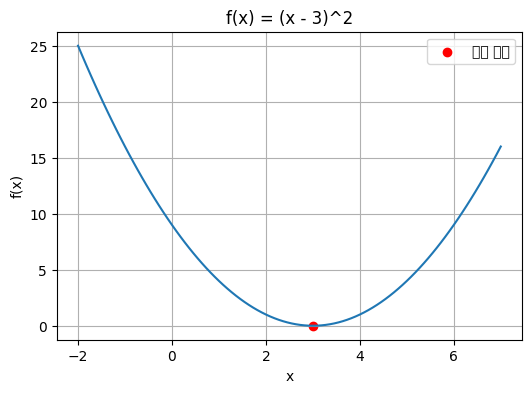

In [ ]:
def f(x):
    return (x - 3) ** 2

def numerical_gradient(func, x, h=1e-5):
    return (func(x + h) - func(x - h)) / (2 * h)

for point in [-1, 0, 2, 3, 5]:
    print(f"x={point:>2}, f(x)={f(point):>5.2f}, 기울기≈{numerical_gradient(f, point):>6.2f}")

xs = np.linspace(-2, 7, 100)
plt.plot(xs, f(xs))
plt.scatter([3], [f(3)], color="red", label="최소 지점")
plt.title("f(x) = (x - 3)^2")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()


## 8) 실습 2: 경사하강법으로 최소값 찾기

현재 위치에서 기울기 방향의 반대로 조금 이동하면 손실이 줄어듭니다.


마지막 x: 3.0
마지막 손실: 0.0


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54624 (\N{HANGUL SYLLABLE HAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

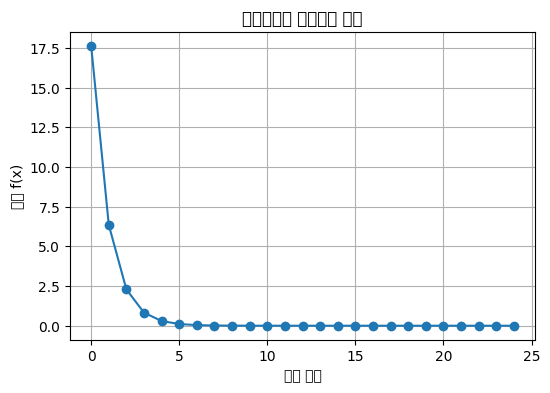

In [ ]:
x_current = -4.0
learning_rate = 0.2
history = []

for step in range(25):
    grad = 2 * (x_current - 3)
    x_current = x_current - learning_rate * grad
    history.append((step, x_current, f(x_current)))

print("마지막 x:", round(x_current, 4))
print("마지막 손실:", round(f(x_current), 6))

history_array = np.array(history)
plt.plot(history_array[:, 0], history_array[:, 2], marker="o")
plt.title("반복할수록 줄어드는 손실")
plt.xlabel("반복 횟수")
plt.ylabel("손실 f(x)")
plt.grid(True)
plt.show()


## 9) 실습 3: 직선 모델을 학습시키기

이제 `y = wx + b` 형태의 모델에서 `w`와 `b`를 직접 업데이트합니다.


학습된 w: 2.039
학습된 b: 0.888
최종 손실: 0.1117


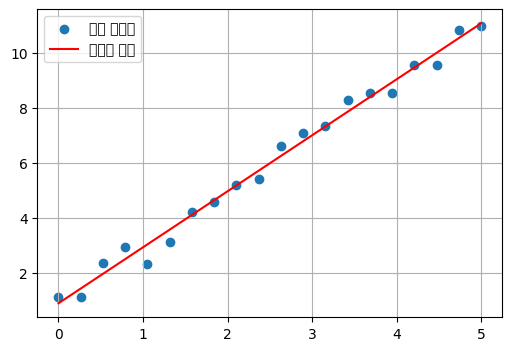

In [ ]:
rng = np.random.default_rng(42)
x_train = np.linspace(0, 5, 20)
y_train = 2.0 * x_train + 1.0 + rng.normal(0, 0.4, size=x_train.shape)

w = 0.0
b = 0.0
lr = 0.03
losses = []

for epoch in range(300):
    y_pred = w * x_train + b
    error = y_pred - y_train
    loss = np.mean(error ** 2)
    losses.append(loss)

    grad_w = 2 * np.mean(error * x_train)
    grad_b = 2 * np.mean(error)
    w -= lr * grad_w
    b -= lr * grad_b

print("학습된 w:", round(w, 3))
print("학습된 b:", round(b, 3))
print("최종 손실:", round(losses[-1], 4))

plt.scatter(x_train, y_train, label="학습 데이터")
plt.plot(x_train, w * x_train + b, color="red", label="학습된 직선")
plt.legend()
plt.grid(True)
plt.show()


## 10) 실습 TODO 1: 학습률 바꾸기

아래 셀에서 `todo_lr`를 바꾸어 손실 변화가 어떻게 달라지는지 확인하세요.


todo_lr: 0.005
마지막 손실: 0.1213

todo_lr: 0.03
마지막 손실: 0.1122

todo_lr: 0.1
마지막 손실: 0.1117

todo_lr: 0.2
마지막 손실: 1.4555322087828047e+105



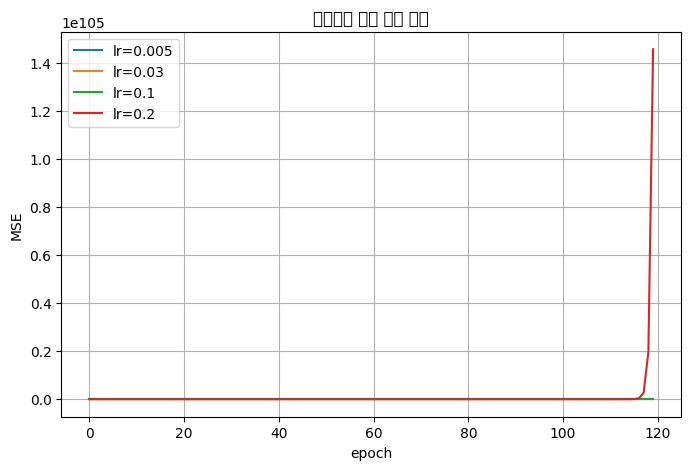

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 학습률 후보
todo_lr = [0.005, 0.03, 0.1, 0.2]

# 학습률별 loss 저장
todo_losses = {}

for lr in todo_lr:
    # 각 학습률마다 초기화
    todo_w, todo_b = 0.0, 0.0

    loss_history = []

    for epoch in range(120):
        # 예측
        todo_pred = todo_w * x_train + todo_b

        # 오차
        todo_error = todo_pred - y_train

        # 손실(MSE)
        loss = np.mean(todo_error ** 2)
        loss_history.append(loss)

        # gradient descent
        grad_w = 2 * np.mean(todo_error * x_train)
        grad_b = 2 * np.mean(todo_error)

        todo_w -= lr * grad_w
        todo_b -= lr * grad_b

    # 학습률별 loss 저장
    todo_losses[lr] = loss_history

    print("todo_lr:", lr)
    print("마지막 손실:", round(loss_history[-1], 4))
    print()

    # 그래프
plt.figure(figsize=(8,5))

for lr in todo_lr:
    plt.plot(todo_losses[lr], label=f"lr={lr}")

plt.title("학습률에 따른 손실 변화")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

todo_lr: 0.1
마지막 손실: 0.1117


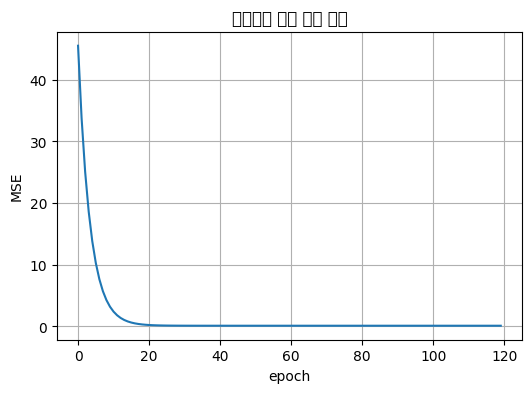

In [ ]:
# TODO 1: 0.005, 0.03, 0.1 등을 넣어 비교해 보세요.
todo_lr = 0.1

todo_w, todo_b = 0.0, 0.0
todo_losses = []

for epoch in range(120):
    todo_pred = todo_w * x_train + todo_b
    todo_error = todo_pred - y_train
    todo_losses.append(np.mean(todo_error ** 2))
    todo_w -= todo_lr * 2 * np.mean(todo_error * x_train)
    todo_b -= todo_lr * 2 * np.mean(todo_error)

print("todo_lr:", todo_lr)
print("마지막 손실:", round(todo_losses[-1], 4))

plt.plot(todo_losses)
plt.title("학습률에 따른 손실 변화")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

## 11) 실습 TODO 2: 목표 직선 바꿔보기

`target_w`, `target_b`를 바꿔 새 데이터를 만들고, 학습 결과가 가까워지는지 확인하세요.


In [ ]:
# TODO 2: target_w와 target_b를 바꿔서 다시 실행해 보세요.
target_w = -1.5
target_b = 4.0

y_todo = target_w * x_train + target_b + rng.normal(0, 0.3, size=x_train.shape)
test_w, test_b = 0.0, 0.0

for epoch in range(250):
    pred = test_w * x_train + test_b
    err = pred - y_todo
    test_w -= 0.03 * 2 * np.mean(err * x_train)
    test_b -= 0.03 * 2 * np.mean(err)

print("목표 w, b:", target_w, target_b)
print("학습된 w, b:", round(test_w, 3), round(test_b, 3))

# target_W  target_b  trained_W  trained_b
# -1.5        4.0      -1.492      3.99
# -1.0        4.0      -0.955      3.838
# -2.0        4.0      -2.015      3.906
# -3.0        4.0      -2.96       3.841
# 0.0         4.0      0.077       3.829
# 2.0         4.0      2.056       3.761
# -1.5        0.0      -1.491      -0.03
# -1.5       -1.0      -1.553      -0.804
# -1.5        1.0      -1.482      0.915
# -1.5        2.0      -1.552      2.07
# -1.5        3.0      -1.458      2.87
# -1.5        5.0      -1.441      4.889
# -1.5        6.0      -1.475      5.838
# -1.5        10.0     -1.439      9.886

목표 w, b: -1.5 4.0
학습된 w, b: -1.433 3.813


## 12) 미니 퀴즈

1. 벡터와 행렬의 차이를 `shape`로 설명해 보세요.
- 벡터는 1차원 데이터로, (n,)
- 행렬은 2차원 데이터로, (r, c)
2. Tensor가 NumPy 배열보다 딥러닝 실습에서 편한 점은 무엇인가요?
- GPU를 활용한 연산에 최적화되어 있다. (병렬 연산)
- 자동미분(autograd) 기능을 제공하여 딥러닝 학습에 적합핟.
3. `requires_grad=True`는 어떤 의미인가요?
- 해당 Tensor에 대한 gradient를 추적하여 자동 미분이 가능하도록 설정한다.
4. `loss.backward()`를 실행하면 어떤 값이 계산되나요?
- loss를 기준으로 각 파라미터의 gradient(미분값)를 계산한다.
5. 경사하강법에서 학습률이 너무 크면 어떤 일이 생길 수 있나요?
- 최적값을 지나치며 진동하거나 발산해서 학습이 실패할 수 있다.


## 13) 오늘의 정리

- 텐서는 숫자를 담는 다차원 배열이며, PyTorch Tensor는 자동미분과 GPU 이동을 지원합니다.
- `loss.backward()`는 손실을 기준으로 파라미터의 gradient를 계산합니다.
- 경사하강법은 파라미터를 조금씩 고쳐 손실을 줄이는 반복 과정입니다.
